# Final Analysis

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load your aggregation file
df = pd.read_csv("Aggregation.csv")

In [3]:
# Define full architecture and seed sets
architectures = [
    "MGT",
    "PIMGT_Internal_Full",
    "PIMGT_Internal_Partial",
    "PIMGT_External_Full",
    "PIMGT_External_Partial"
]
seeds = ["25", "42", "79"]

In [4]:
# Create architecture-specific DataFrames
arch_dfs = {arch: df[[col for col in df.columns if col.startswith(f"{arch}_")]] for arch in architectures}

# Create seed-specific DataFrames
seed_dfs = {seed: df[[col for col in df.columns if f"_seed{seed}_" in col]] for seed in seeds}

In [5]:
def ensure_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

In [6]:
def plot_metric_lines(df, metric, title, figsize=(10, 6)):
    metric_lower = metric.lower()
    folder = metric_lower  # e.g., "rmse"
    ensure_dir(folder)

    plt.figure(figsize=figsize)
    for col in df.columns:
        if metric_lower in col.lower():
            plt.plot(df.index, df[col], label=col)

    plt.xlabel("Prediction Step")
    plt.ylabel(metric.upper() if metric_lower != "mape" else "MAPE (%)")
    plt.title(title)
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.grid(True)
    plt.tight_layout()
    
    # Save plot inside the folder
    filename = os.path.join(folder, f"{title}.png")
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

In [7]:
def plot_rmse_lines(df, title, figsize=(10, 6)):
    plot_metric_lines(df, "rmse", title, figsize)

def plot_mae_lines(df, title, figsize=(10, 6)):
    plot_metric_lines(df, "mae", title, figsize)

def plot_mape_lines(df, title, figsize=(10, 6)):
    plot_metric_lines(df, "mape", title, figsize)

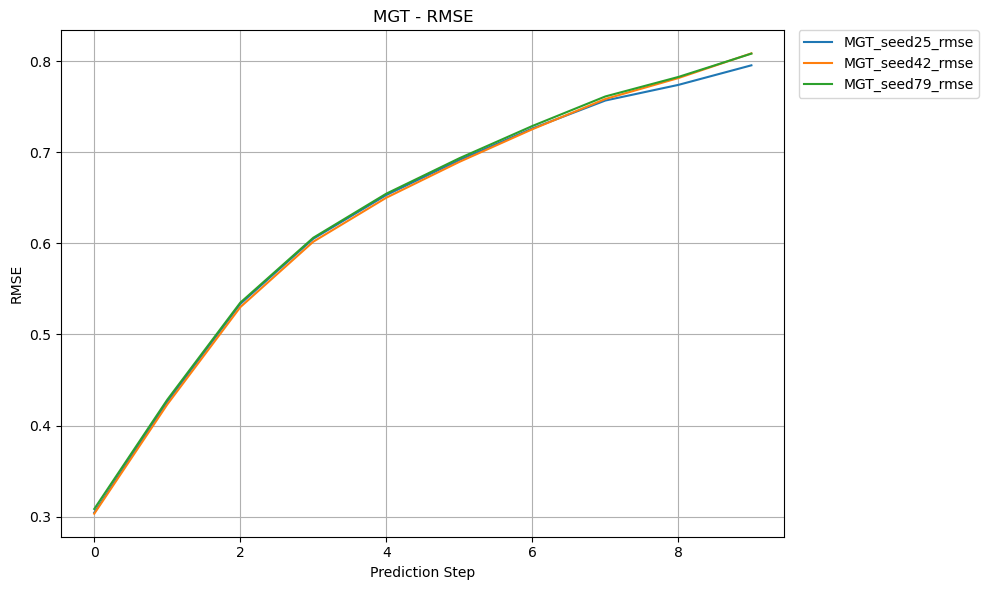

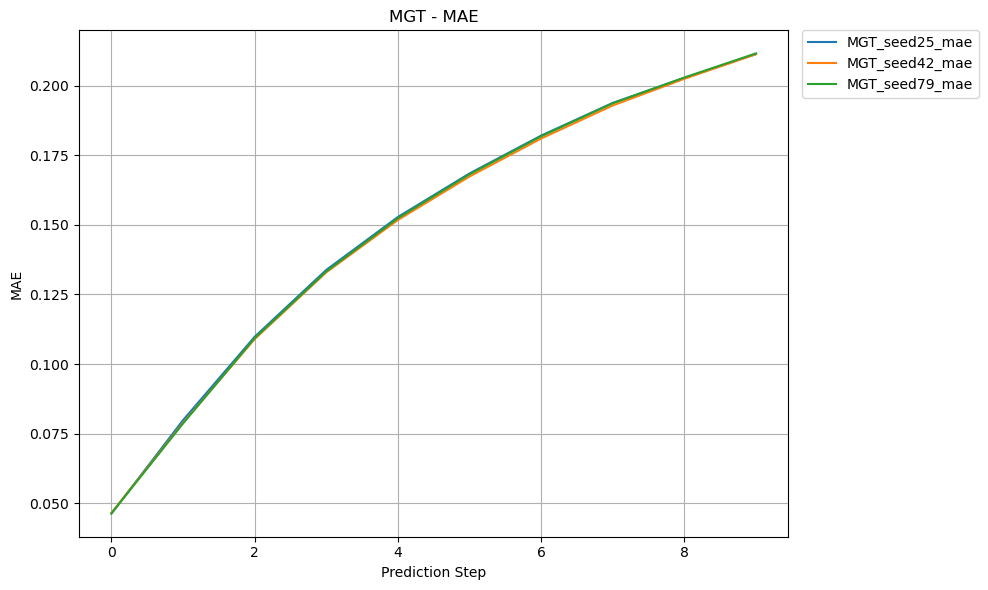

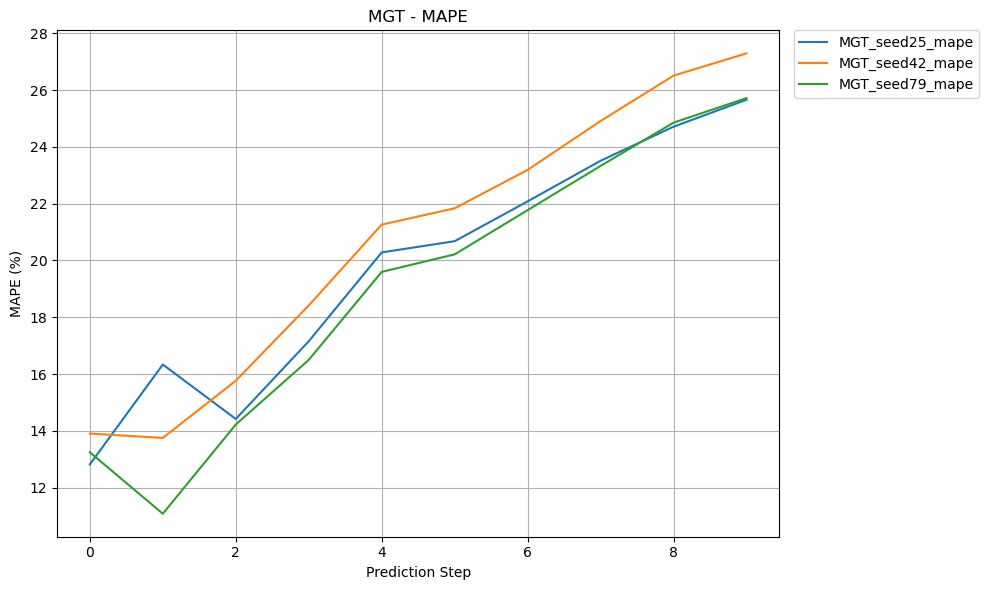

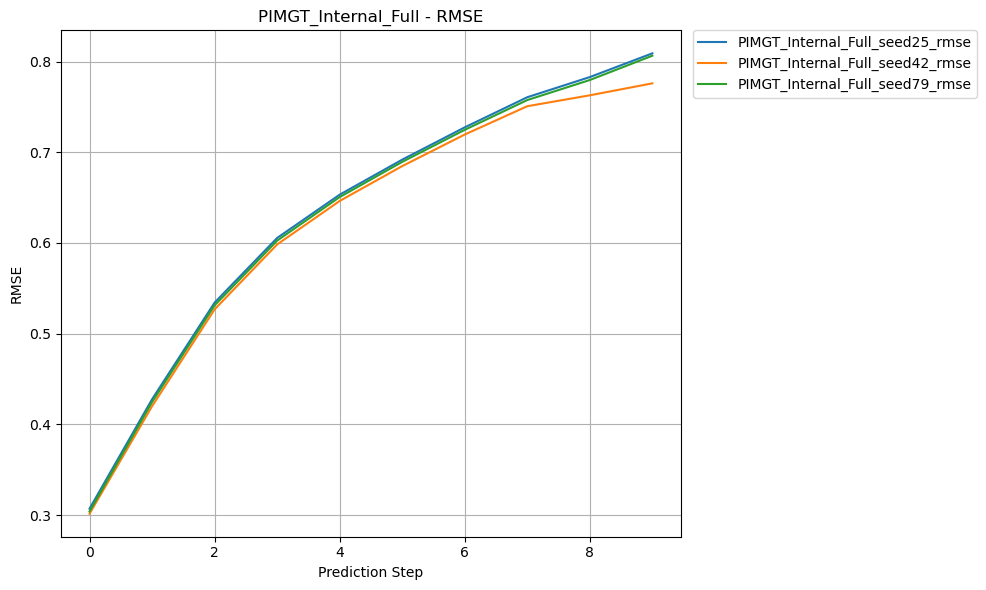

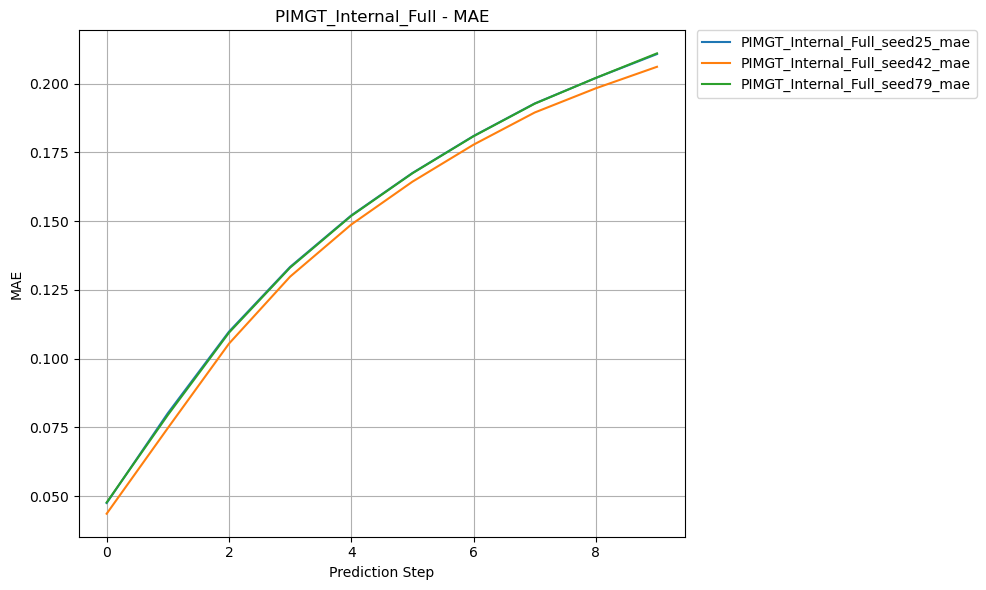

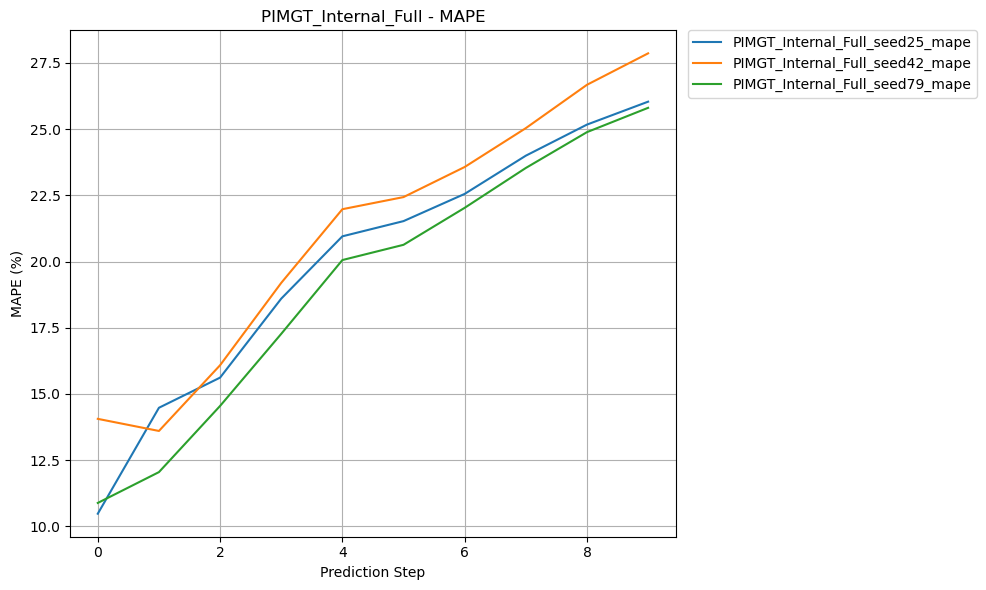

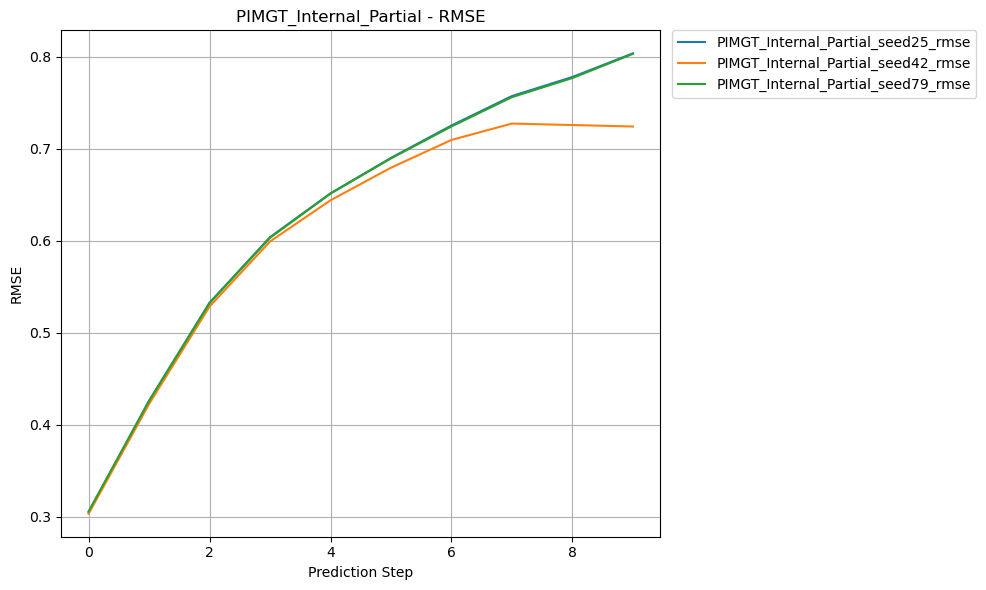

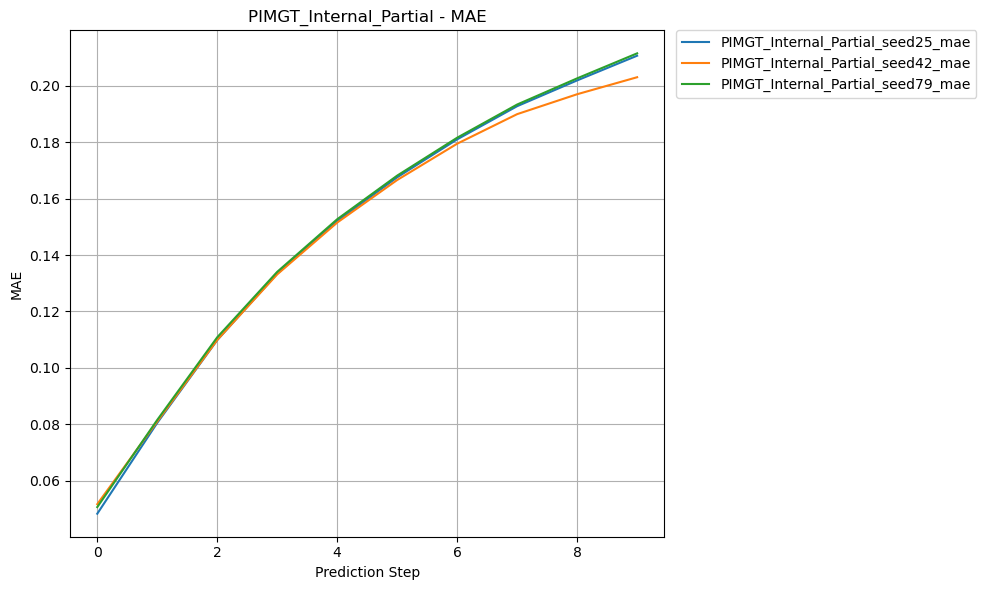

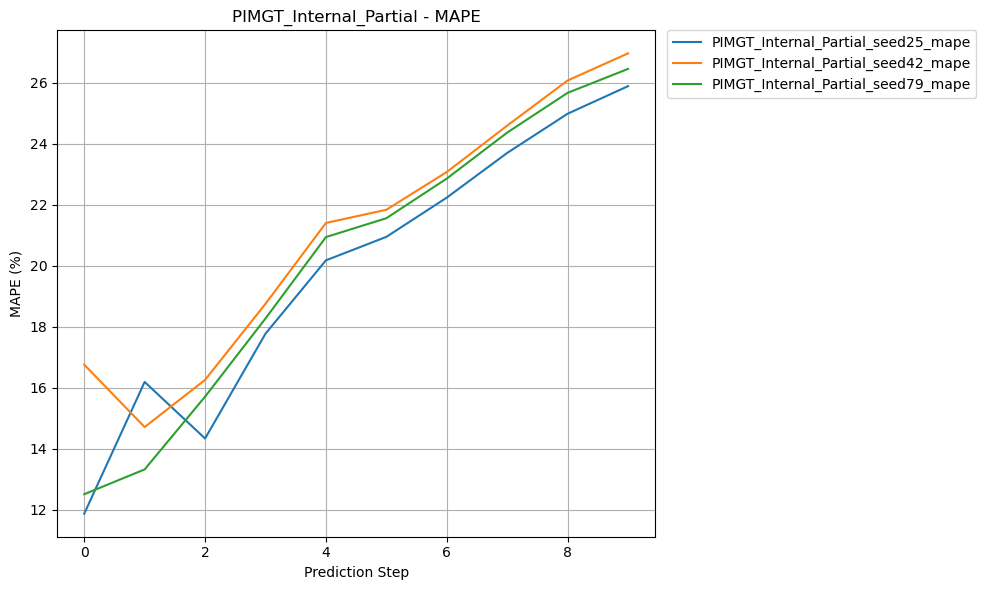

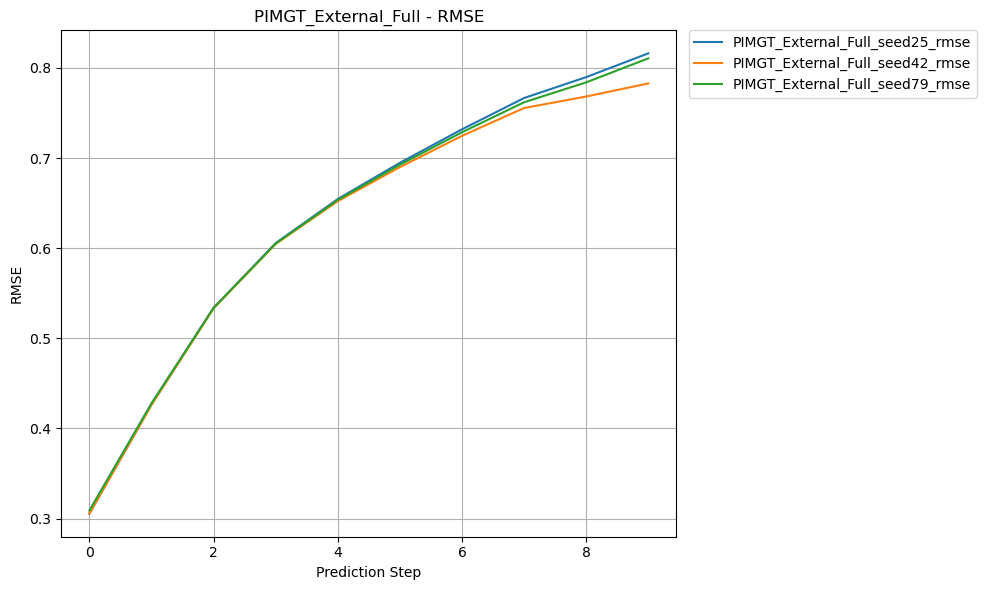

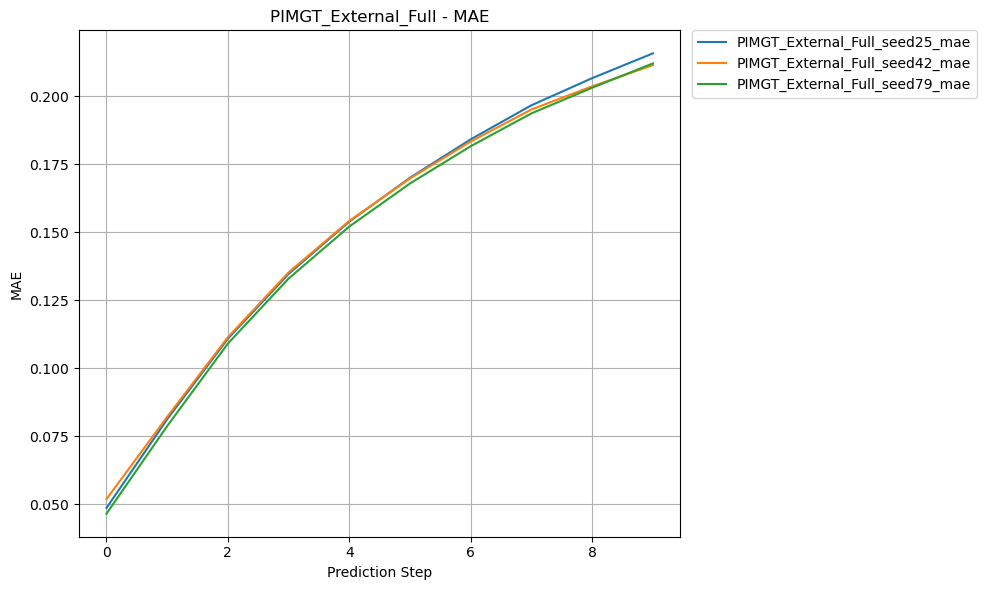

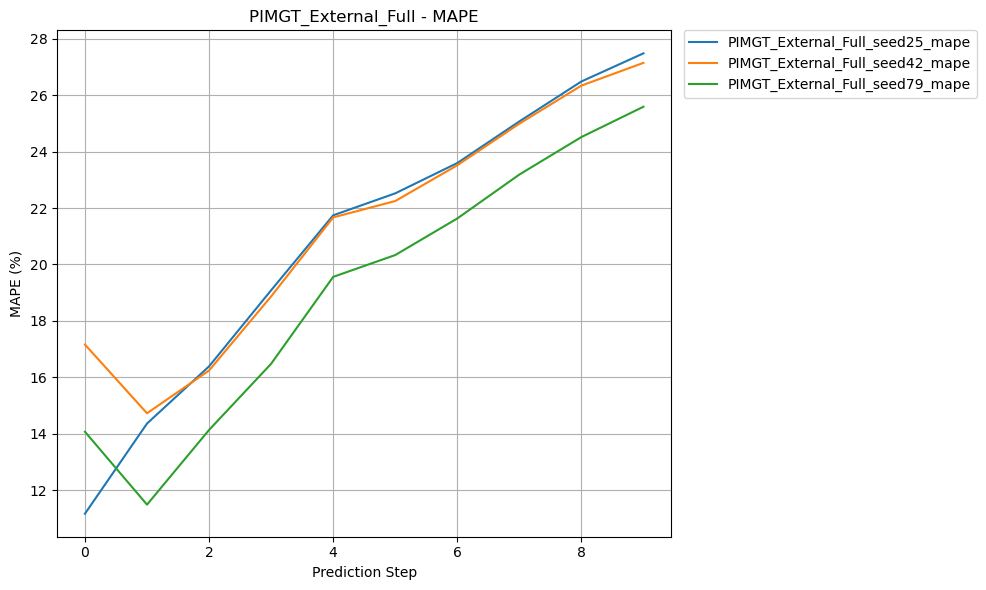

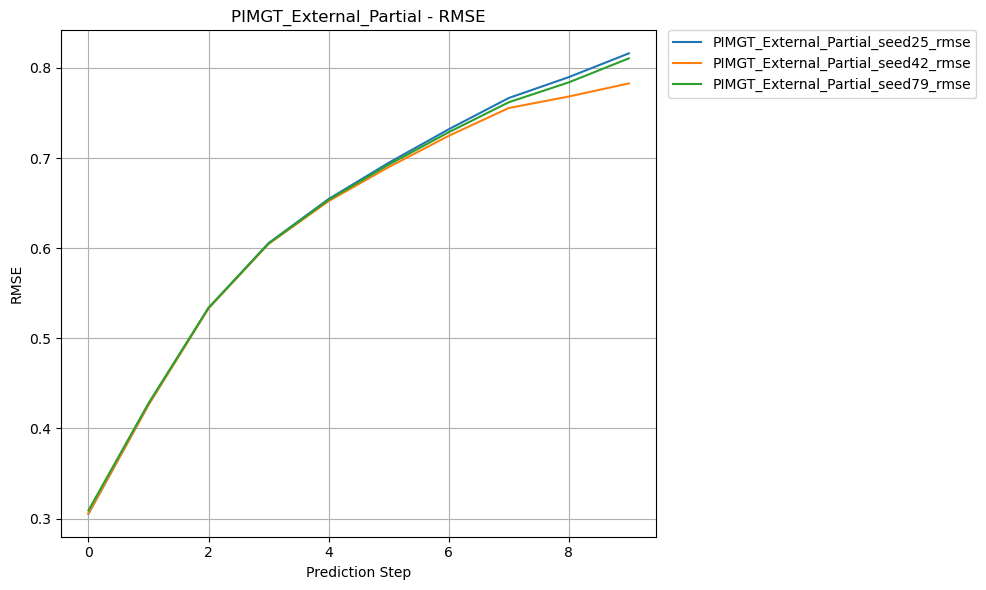

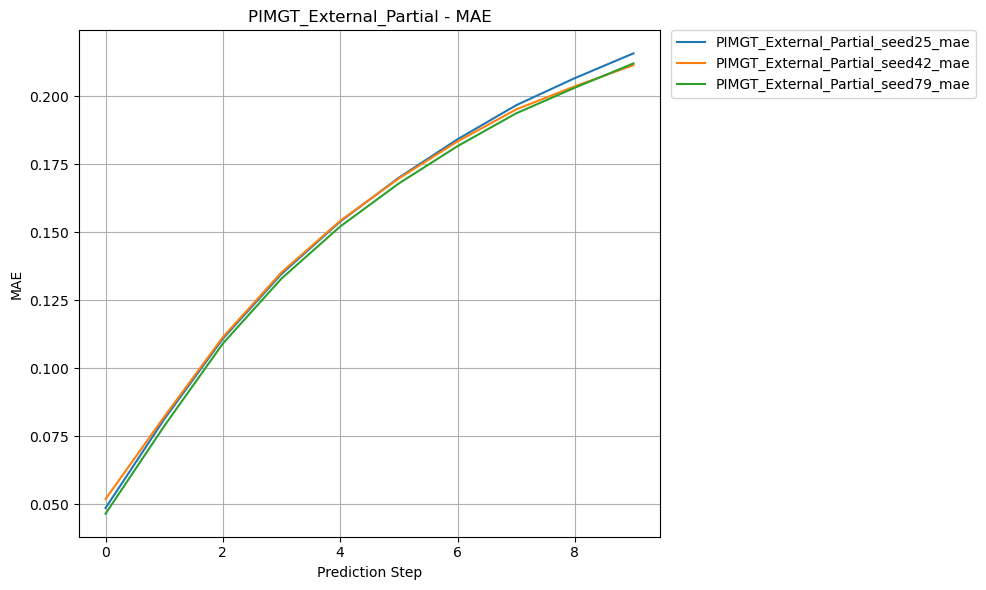

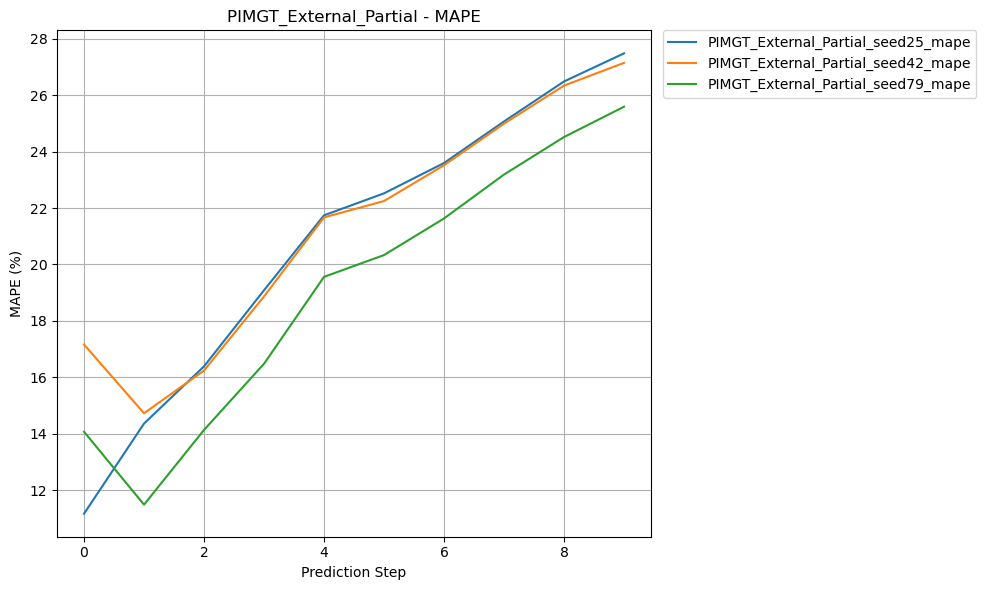

In [8]:
# Architecture plots
for arch in architectures:
    plot_rmse_lines(arch_dfs[arch], title=f"{arch} - RMSE")
    plot_mae_lines(arch_dfs[arch], title=f"{arch} - MAE")
    plot_mape_lines(arch_dfs[arch], title=f"{arch} - MAPE")

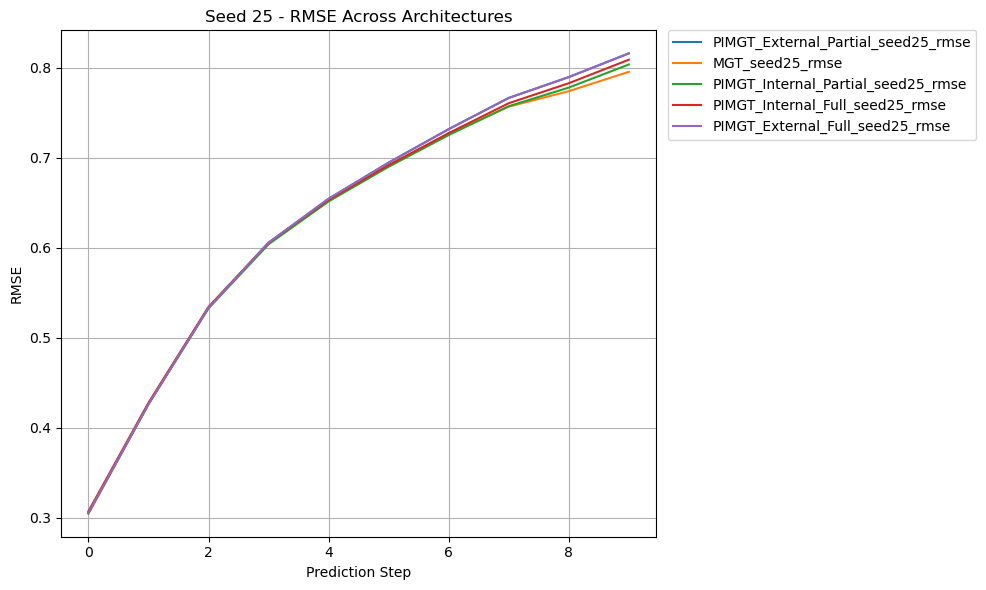

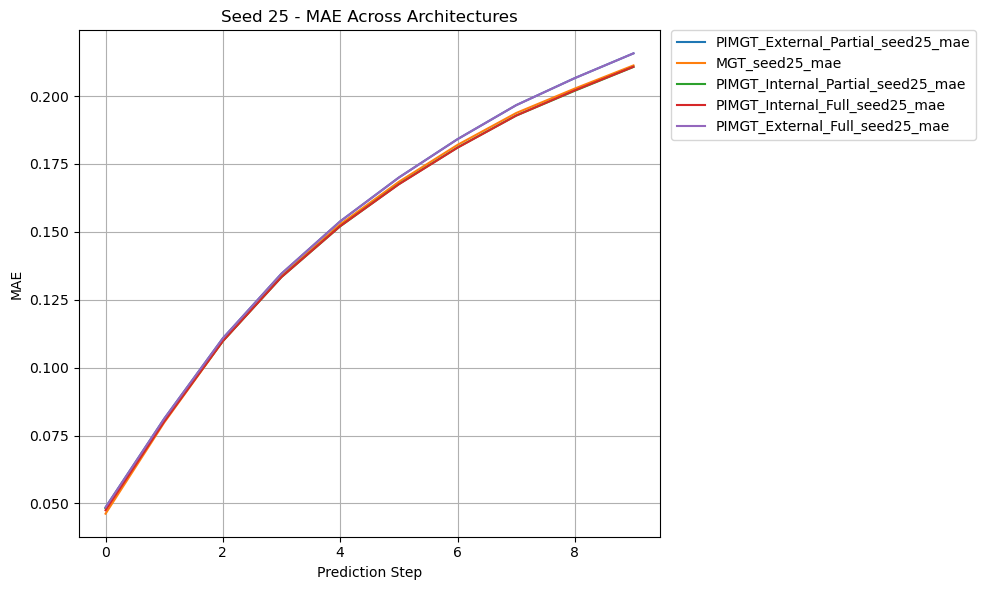

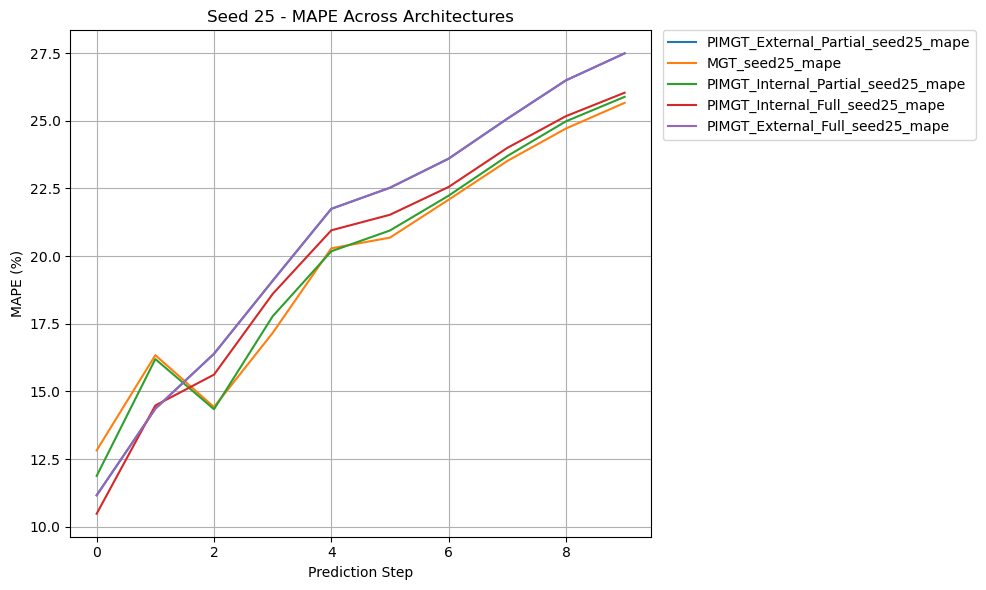

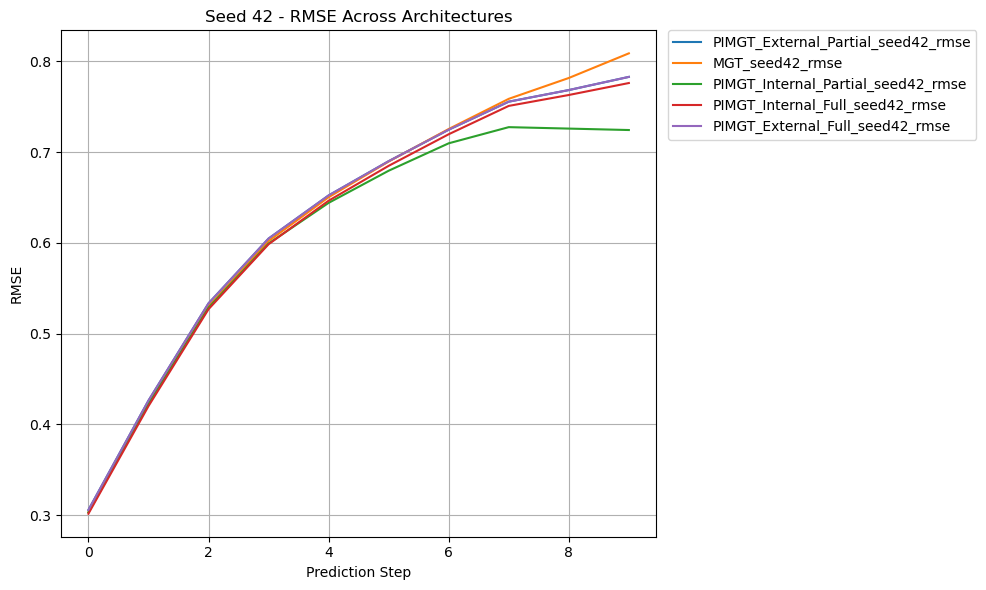

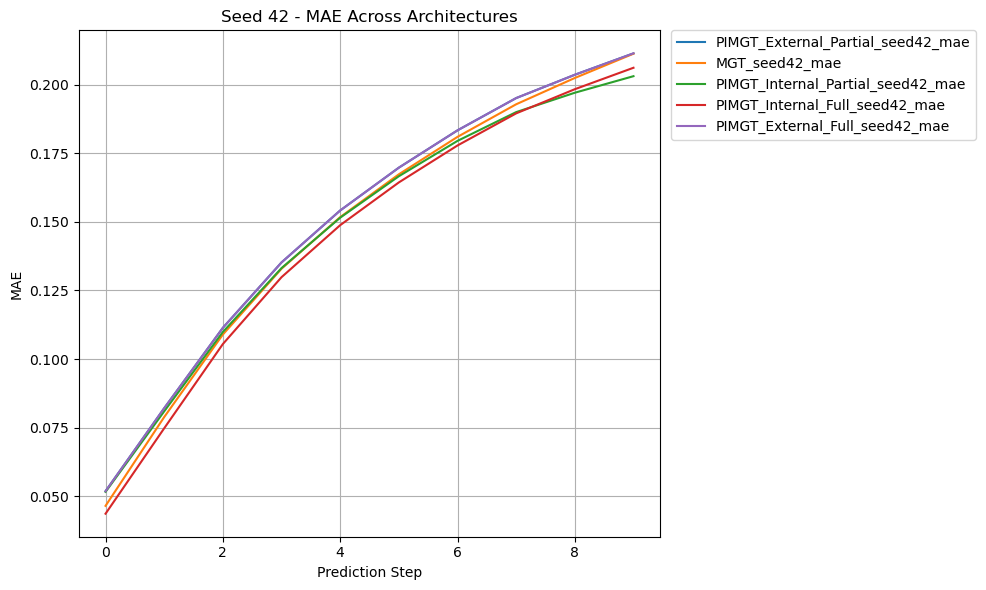

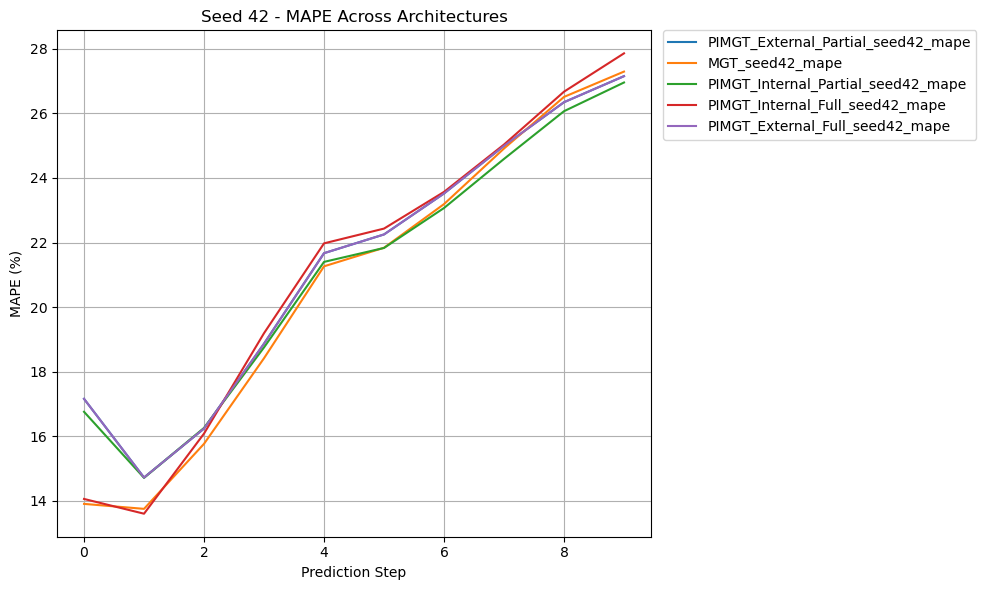

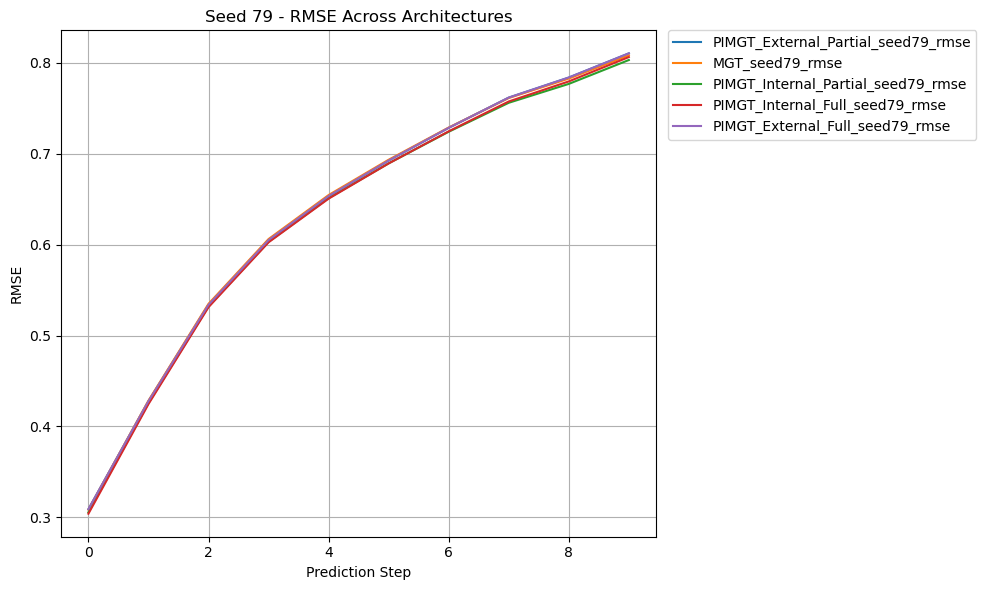

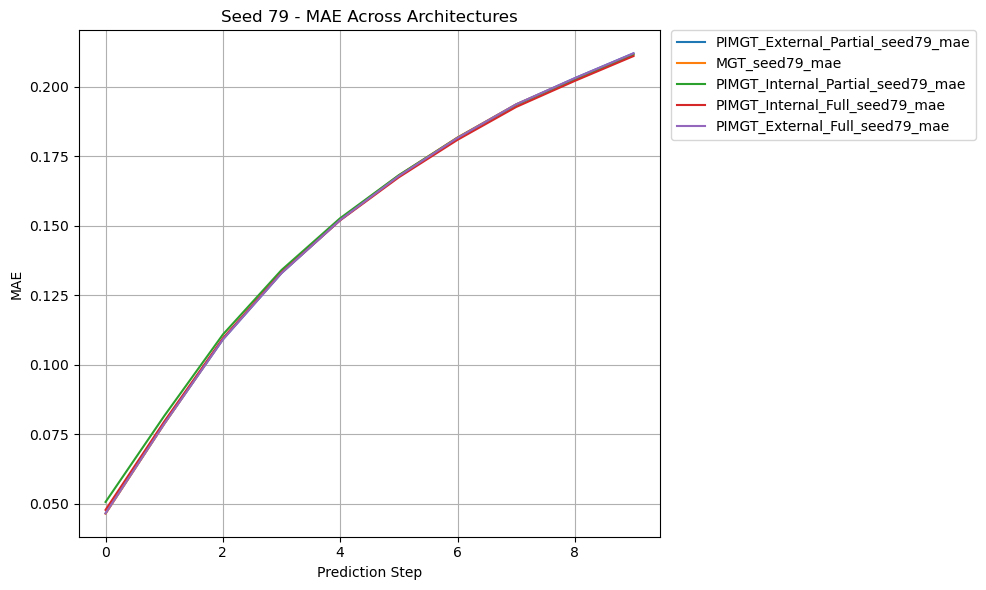

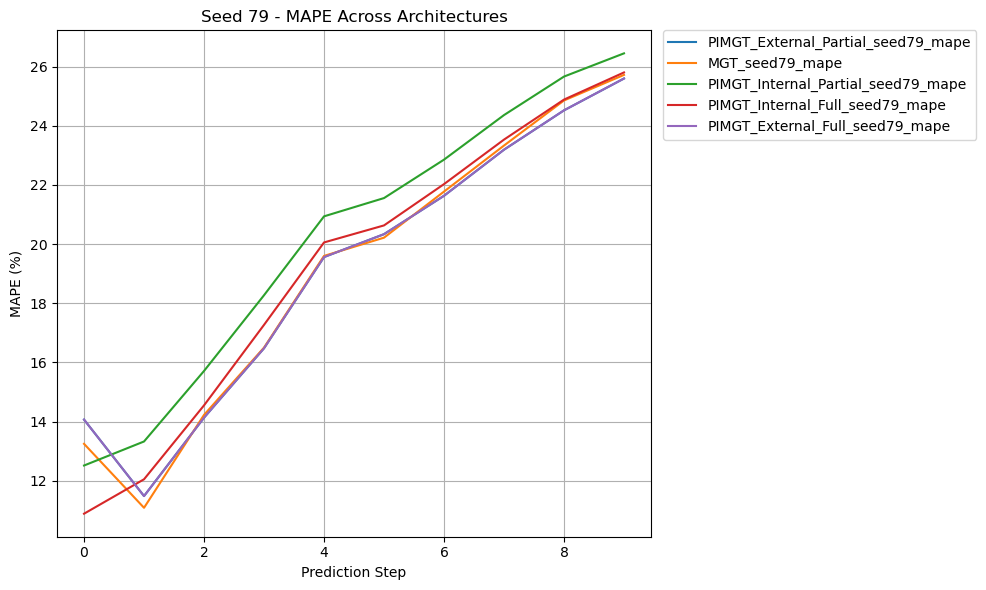

In [9]:
# Seed plots
for seed in seeds:
    plot_rmse_lines(seed_dfs[seed], title=f"Seed {seed} - RMSE Across Architectures")
    plot_mae_lines(seed_dfs[seed], title=f"Seed {seed} - MAE Across Architectures")
    plot_mape_lines(seed_dfs[seed], title=f"Seed {seed} - MAPE Across Architectures")
